# Urdu Sentiment Analysis — Hugging Face Trainer (MacBook Air 2025 GPU-Only)
### Transformers + PEFT LoRA + Apple Silicon MPS (Python 3.9)

| Property | Value |
|---|---|
| **Model** | `distilbert-base-multilingual-cased` |
| **Framework** | Hugging Face `Trainer` API |
| **Task** | Binary sentiment classification (negative/positive) |
| **Runtime** | Apple Silicon GPU only (`mps`) |
| **Python** | 3.9 compatible setup |

## Section 0 — Installation

In [ ]:
import subprocess, sys

print(f"Installing into: {sys.executable}")  

packages = [
    'torch==2.4.1',
    'torchvision==0.19.1',
    'torchaudio==2.4.1',
    'numpy==1.26.4',
    'transformers==4.41.2',
    'datasets==2.19.1',
    'peft==0.11.1',
    'accelerate==0.31.0',
    'sentencepiece==0.2.0',
    'scikit-learn==1.4.2',
    'matplotlib==3.8.0',
    'seaborn==0.12.2',
    'tqdm',
    'pandas',
    'urllib3<2.0',
    'ipywidgets',
]

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--no-cache-dir'] + packages)
print("\n✅ Done — now restart the kernel once")

Installing into: /opt/homebrew/opt/python@3.11/bin/python3.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 1.6 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]

✅ Done — now restart the kernel once



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [5]:
# Section 1 — Imports and runtime configuration
# ── Must be set BEFORE any huggingface/torch imports ──────────────────────────
import os
os.environ['HF_DATASETS_OFFLINE']        = '1'
os.environ['TRANSFORMERS_OFFLINE']       = '1'
os.environ['HF_HUB_OFFLINE']            = '1'
os.environ['HF_HUB_DISABLE_TELEMETRY']  = '1'
os.environ['TOKENIZERS_PARALLELISM']     = 'false'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

# ── Standard library ──────────────────────────────────────────────────────────
import re
import sys
import random
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Data / viz ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch

# ── HuggingFace ───────────────────────────────────────────────────────────────
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, TaskType

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    precision_recall_fscore_support, classification_report,
)
from sklearn.model_selection import train_test_split

# ── Paths ─────────────────────────────────────────────────────────────────────
SEED     = 42
BASE_DIR = os.getcwd()
URDU_TSV  = os.path.join(BASE_DIR, 'urdu-sentiment-corpus-v1.tsv')
ROMAN_CSV = os.path.join(BASE_DIR, 'Roman Urdu DataSet.csv')
DARAZ_CSV = os.path.join(BASE_DIR, 'darazreviews.csv')

# ── Device — MPS only ─────────────────────────────────────────────────────────
if not torch.backends.mps.is_available():
    raise RuntimeError(
        'Apple GPU (MPS) is not available. '
        'This notebook is configured for GPU-only execution.'
    )
DEVICE = 'mps'

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'Python   : {sys.version.split()[0]}')
print(f'NumPy    : {np.__version__}')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}  (Apple Silicon MPS)')
print(f'BASE_DIR : {BASE_DIR}')
print('\n✅ Environment ready — MPS GPU-only mode enabled')

Python   : 3.11.14
NumPy    : 1.26.4
PyTorch  : 2.4.1
Device   : mps  (Apple Silicon MPS)
BASE_DIR : /Users/falakhakeem/Desktop/CSCI316_PROJECT_2

✅ Environment ready — MPS GPU-only mode enabled


## Section 2 — Dataset Discovery and Validation

In [ ]:

from pathlib import Path

FILE_NAMES = {
    'daraz': 'darazreviews.csv',
    'roman': 'Roman Urdu DataSet.csv',
    'urdu_tsv': 'urdu-sentiment-corpus-v1.tsv',
}


PROJECT_DIR = Path.cwd()
SEARCH_DIRS = [PROJECT_DIR]


for sub in PROJECT_DIR.iterdir():
    if sub.is_dir() and sub.name not in {'.git', '__pycache__', '.ipynb_checkpoints'}:
        SEARCH_DIRS.append(sub)

DATA_FILES = {}
missing = []

for key, filename in FILE_NAMES.items():
    found = None
    for folder in SEARCH_DIRS:
        candidate = folder / filename
        if candidate.exists():
            found = candidate
            break

    if found is None:
        missing.append(filename)
    else:
        DATA_FILES[key] = str(found)

if missing:
    searched = '\n'.join([f'  - {p}' for p in SEARCH_DIRS])
    raise FileNotFoundError(
        'Missing dataset file(s): ' + ', '.join(missing) + '\n'
        f'Searched:\n{searched}\n'
        'Place the CSV/TSV files in the project root and re-run this cell.'
    )

print('All dataset files found:')
for key, value in DATA_FILES.items():
    print(f'  {key}: {value}')

All dataset files found:
  daraz: /Users/falakhakeem/Desktop/CSCI316_PROJECT_2/darazreviews.csv
  roman: /Users/falakhakeem/Desktop/CSCI316_PROJECT_2/Roman Urdu DataSet.csv
  urdu_tsv: /Users/falakhakeem/Desktop/CSCI316_PROJECT_2/urdu-sentiment-corpus-v1.tsv


In [7]:
# Validate resolved dataset paths before preprocessing
required_keys = ['daraz', 'roman', 'urdu_tsv']
for k in required_keys:
    if k not in DATA_FILES:
        raise KeyError(f"DATA_FILES is missing key: {k}. Re-run dataset discovery cells.")
    p = Path(DATA_FILES[k])
    if not p.exists():
        raise FileNotFoundError(
            f"Resolved path does not exist: {p}\n"
            "Re-run dataset discovery cells and verify the dataset files are in this workspace."
        )
print('Dataset paths validated successfully.')

Dataset paths validated successfully.


In [8]:
def clean_text(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_label(x):
    x = str(x).strip().lower()
    mapping = {
        'positive': 'positive', 'pos': 'positive', 'p': 'positive', '1': 'positive',
        'negative': 'negative', 'neg': 'negative', 'n': 'negative', '0': 'negative',
        'neutral': 'neutral', 'neu': 'neutral', 'o': 'neutral'
    }
    return mapping.get(x, x)

def load_daraz(path):
    df = pd.read_csv(path, engine='python', on_bad_lines='skip')
    review_col, sentiment_col, rating_col = None, None, None

    for c in df.columns:
        c_low = c.lower()
        if review_col is None and 'review' in c_low:
            review_col = c
        if sentiment_col is None and 'sentiment' in c_low:
            sentiment_col = c
        if rating_col is None and 'rating' in c_low:
            rating_col = c

    if review_col is None:
        raise ValueError('Could not detect review column in darazreviews.csv')

    out = pd.DataFrame({'text': df[review_col].astype(str)})

    if sentiment_col is not None:
        out['label'] = df[sentiment_col].astype(str).map(normalize_label)
    elif rating_col is not None:
        ratings = pd.to_numeric(df[rating_col], errors='coerce').fillna(3)
        out['label'] = np.where(ratings >= 3, 'positive', 'negative')
    else:
        out['label'] = 'positive'

    return out

def load_roman(path):
    df = pd.read_csv(path, header=None, names=['text', 'label', 'extra'], engine='python', on_bad_lines='skip')
    out = df[['text', 'label']].copy()
    out['label'] = out['label'].map(normalize_label)
    return out

def load_urdu_tsv(path):
    df = pd.read_csv(path, sep='\t', engine='python', on_bad_lines='skip')
    text_col = 'Tweet' if 'Tweet' in df.columns else df.columns[0]
    label_col = 'Class' if 'Class' in df.columns else df.columns[-1]
    out = pd.DataFrame({'text': df[text_col].astype(str), 'label': df[label_col].astype(str).map(normalize_label)})
    return out

daraz_df = load_daraz(DATA_FILES['daraz'])
roman_df = load_roman(DATA_FILES['roman'])
urdu_df = load_urdu_tsv(DATA_FILES['urdu_tsv'])

data = pd.concat([daraz_df, roman_df, urdu_df], ignore_index=True)
data['text'] = data['text'].astype(str).map(clean_text)
data['label'] = data['label'].astype(str).map(normalize_label)
data = data[data['label'].isin(['positive', 'negative'])].copy()
data = data[data['text'].str.len() > 2].drop_duplicates(subset=['text'])
data = data.reset_index(drop=True)

label2id = {'negative': 0, 'positive': 1}
id2label = {v: k for k, v in label2id.items()}
data['label'] = data['label'].map(label2id)

train_df, test_df = train_test_split(data[['text', 'label']], test_size=0.2, random_state=SEED, stratify=data['label'])

print('Merged dataset size:', len(data))
print('Train/Test:', len(train_df), len(test_df))

Merged dataset size: 15309
Train/Test: 12247 3062


## Section 3 — Tokenization and Hugging Face Datasets

In [ ]:
MODEL_NAME = 'distilbert-base-multilingual-cased'
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 4  

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_batch(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LEN)

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

train_ds = train_ds.map(tokenize_batch, batched=True)
test_ds = test_ds.map(tokenize_batch, batched=True)

train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c not in ['input_ids', 'attention_mask', 'label']])
test_ds = test_ds.remove_columns([c for c in test_ds.column_names if c not in ['input_ids', 'attention_mask', 'label']])

train_ds.set_format(type='torch')
test_ds.set_format(type='torch')

Map: 100%|██████████| 3062/3062 [00:00<00:00, 15675.39 examples/s]


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

def show_confusion(trainer, dataset, title):
    output = trainer.predict(dataset)
    preds = np.argmax(output.predictions, axis=1)
    labels = output.label_ids
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    return labels, preds

## Section 4 — Trainer Strategies (Full FT and LoRA)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MPS available: True


  3%|▎         | 50/1528 [01:48<55:36,  2.26s/it]  

{'loss': 0.6784, 'grad_norm': 1.3764581680297852, 'learning_rate': 1.9345549738219897e-05, 'epoch': 0.13}


  7%|▋         | 100/1528 [03:22<44:19,  1.86s/it]

...

                                                     
100%|██████████| 1528/1528 [9:51:23<00:00, 23.22s/it]


{'eval_loss': 0.5043439269065857, 'eval_accuracy': 0.7942521227955585, 'eval_precision': 0.827049670855775, 'eval_recall': 0.8020893789901334, 'eval_f1': 0.8143783146729523, 'eval_runtime': 31.3839, 'eval_samples_per_second': 97.566, 'eval_steps_per_second': 24.407, 'epoch': 3.99}
{'train_runtime': 35483.9819, 'train_samples_per_second': 1.381, 'train_steps_per_second': 0.043, 'train_loss': 0.4116928621112364, 'epoch': 3.99}


100%|██████████| 766/766 [00:30<00:00, 24.98it/s]


{'eval_loss': 0.5043439269065857, 'eval_accuracy': 0.7942521227955585, 'eval_precision': 0.827049670855775, 'eval_recall': 0.8020893789901334, 'eval_f1': 0.8143783146729523, 'eval_runtime': 30.698, 'eval_samples_per_second': 99.746, 'eval_steps_per_second': 24.953, 'epoch': 3.992161985630307}


100%|██████████| 766/766 [00:31<00:00, 24.60it/s]


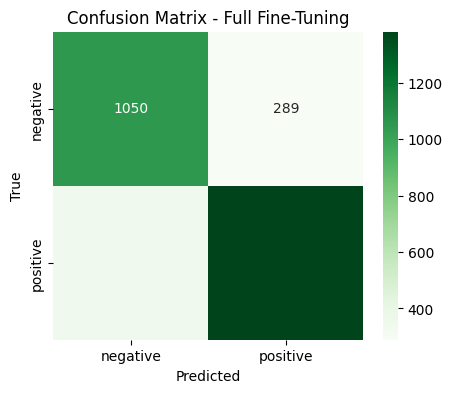

In [ ]:
import os, gc, torch

gc.collect()
torch.mps.empty_cache()
torch.mps.synchronize()

# Confirm MPS is actually available
assert torch.backends.mps.is_available(), "MPS not available!"
print(f"MPS available: {torch.backends.mps.is_available()}")

full_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    local_files_only=True,
    torch_dtype=torch.float32,
).to('mps')

full_args = TrainingArguments(
    output_dir='outputs/full_finetune',
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    report_to='none',
    fp16=False,
    bf16=False,
    
    dataloader_num_workers=0,
    gradient_accumulation_steps=8,
)

full_trainer = Trainer(
    model=full_model,
    args=full_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

torch.mps.empty_cache()
full_trainer.train()
full_metrics = full_trainer.evaluate()
print(full_metrics)
_ = show_confusion(full_trainer, test_ds, 'Confusion Matrix - Full Fine-Tuning')

 22%|██▏       | 683/3064 [07:42<26:51,  1.48it/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 813,314 || all params: 136,139,524 || trainable%: 0.5974


  3%|▎         | 50/1532 [00:28<17:27,  1.41it/s]

{'loss': 0.6914, 'grad_norm': 2.458840847015381, 'learning_rate': 6.493506493506494e-05, 'epoch': 0.13}


  7%|▋         | 100/1532 [00:45<02:30,  9.50it/s]

...

100%|██████████| 1532/1532 [11:31<00:00,  2.22it/s]


{'eval_loss': 0.48863136768341064, 'eval_accuracy': 0.7691051600261267, 'eval_precision': 0.796037296037296, 'eval_recall': 0.7928032501450958, 'eval_f1': 0.7944169816807212, 'eval_runtime': 43.4864, 'eval_samples_per_second': 70.413, 'eval_steps_per_second': 1.104, 'epoch': 4.0}
{'train_runtime': 691.3436, 'train_samples_per_second': 70.859, 'train_steps_per_second': 2.216, 'train_loss': 0.5284014600997805, 'epoch': 4.0}


100%|██████████| 48/48 [00:42<00:00,  1.13it/s]


{'eval_loss': 0.48863136768341064, 'eval_accuracy': 0.7691051600261267, 'eval_precision': 0.796037296037296, 'eval_recall': 0.7928032501450958, 'eval_f1': 0.7944169816807212, 'eval_runtime': 43.437, 'eval_samples_per_second': 70.493, 'eval_steps_per_second': 1.105, 'epoch': 4.0}


100%|██████████| 48/48 [00:48<00:00,  1.00s/it]


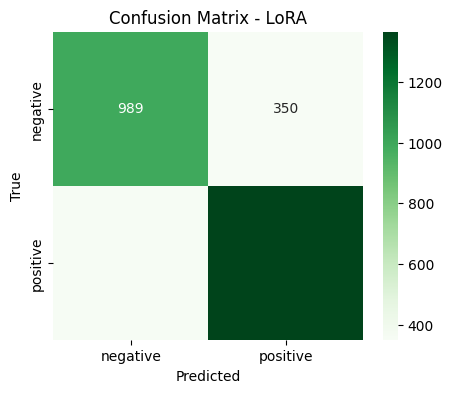

In [ ]:
# Section 6B — Strategy 2: LoRA PEFT 
import gc

gc.collect()
torch.mps.empty_cache()
torch.mps.synchronize()

assert torch.backends.mps.is_available(), "MPS not available!"

lora_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    local_files_only=True,
    torch_dtype=torch.float32,
).to('mps')

lora_base.config.hidden_dropout_prob           = 0.0
lora_base.config.attention_probs_dropout_prob  = 0.0

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.0,
    target_modules=['q_lin', 'k_lin', 'v_lin']
)

lora_model = get_peft_model(lora_base, lora_config)
lora_model.print_trainable_parameters()

lora_args = TrainingArguments(
    output_dir='outputs/lora',
    learning_rate=2e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    report_to='none',
    fp16=False,
    bf16=False,
    dataloader_num_workers=0,
    gradient_accumulation_steps=1,
    dataloader_pin_memory=False,
    optim='adamw_torch',            
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    group_by_length=True,
)

lora_trainer = Trainer(
    model=lora_model,
    args=lora_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

torch.mps.empty_cache()
lora_trainer.train()
lora_metrics = lora_trainer.evaluate()
print(lora_metrics)
_ = show_confusion(lora_trainer, test_ds, 'Confusion Matrix - LoRA')

In [18]:
comparison = pd.DataFrame([
    {
        'method': 'Full Fine-Tuning',
        'accuracy': full_metrics.get('eval_accuracy', np.nan),
        'precision': full_metrics.get('eval_precision', np.nan),
        'recall': full_metrics.get('eval_recall', np.nan),
        'f1': full_metrics.get('eval_f1', np.nan),
    },
    {
        'method': 'LoRA',
        'accuracy': lora_metrics.get('eval_accuracy', np.nan),
        'precision': lora_metrics.get('eval_precision', np.nan),
        'recall': lora_metrics.get('eval_recall', np.nan),
        'f1': lora_metrics.get('eval_f1', np.nan),
    }
])
comparison = comparison.sort_values('f1', ascending=False).reset_index(drop=True)
comparison

,method,accuracy,precision,recall,f1
0,Full Fine-Tuning,0.794252,0.827050,0.802089,0.814378
1,LoRA,0.769105,0.796037,0.792803,0.794417


100%|██████████| 48/48 [00:25<00:00,  1.89it/s]

Full Fine-Tuning — Classification Report
              precision    recall  f1-score   support

    negative       0.75      0.78      0.77      1339
    positive       0.83      0.80      0.81      1723

    accuracy                           0.79      3062
   macro avg       0.79      0.79      0.79      3062
weighted avg       0.80      0.79      0.79      3062

LoRA — Classification Report
              precision    recall  f1-score   support

    negative       0.73      0.74      0.74      1339
    positive       0.80      0.79      0.79      1723

    accuracy                           0.77      3062
   macro avg       0.77      0.77      0.77      3062
weighted avg       0.77      0.77      0.77      3062

Detailed comparison metrics:


,method,accuracy,precision,recall,f1,f1_macro,f1_weighted,f1_negative,f1_positive
0,Full Fine-Tuning,0.7943,0.827,0.8021,0.8144,0.7918,0.7946,0.7692,0.8144
1,LoRA,0.7691,0.796,0.7928,0.7944,0.7656,0.7692,0.7367,0.7944


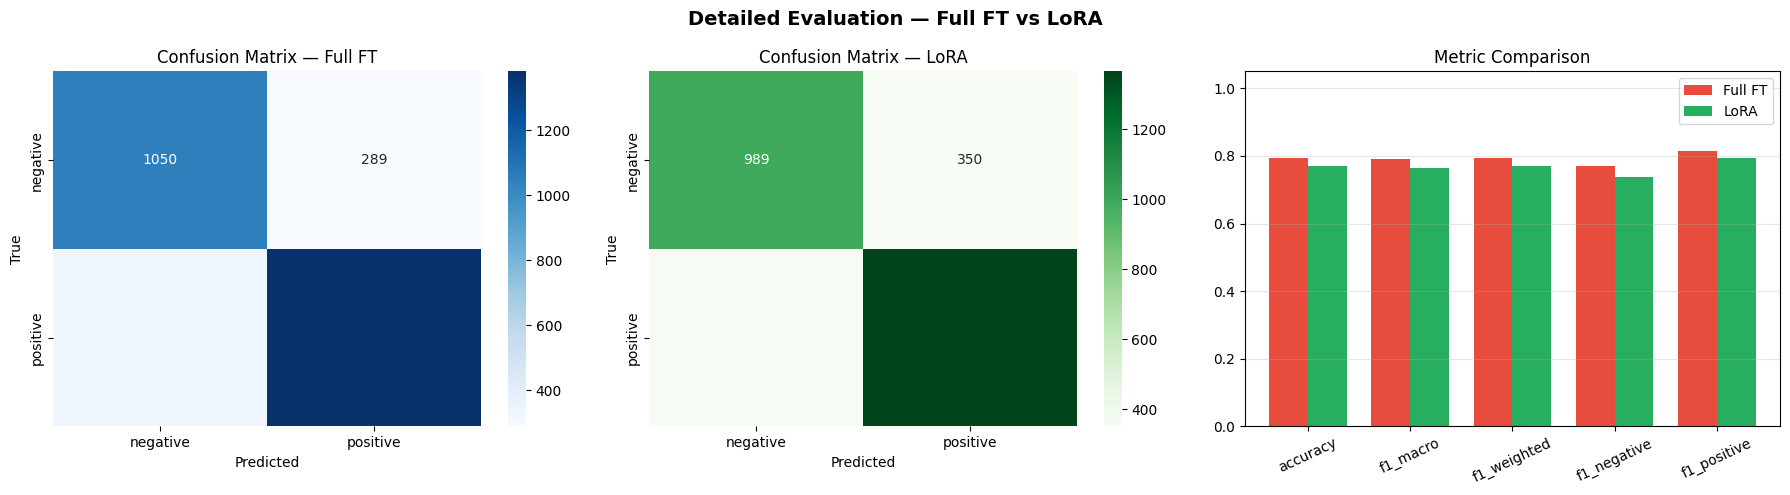

In [19]:
# Detailed test-set evaluation for both strategies
def get_preds_labels(trainer, dataset):
    out = trainer.predict(dataset)
    preds = np.argmax(out.predictions, axis=1)
    labels = out.label_ids
    return labels, preds

def detailed_metrics(labels, preds):
    p_bin, r_bin, f1_bin, _ = precision_recall_fscore_support(
        labels, preds, average='binary', zero_division=0
    )
    f1_per_class = f1_score(labels, preds, average=None, labels=[0, 1], zero_division=0)
    return {
        'accuracy': round(accuracy_score(labels, preds), 4),
        'precision': round(float(p_bin), 4),
        'recall': round(float(r_bin), 4),
        'f1': round(float(f1_bin), 4),
        'f1_macro': round(f1_score(labels, preds, average='macro', zero_division=0), 4),
        'f1_weighted': round(f1_score(labels, preds, average='weighted', zero_division=0), 4),
        'f1_negative': round(float(f1_per_class[0]), 4),
        'f1_positive': round(float(f1_per_class[1]), 4),
    }

full_labels, full_preds = get_preds_labels(full_trainer, test_ds)
lora_labels, lora_preds = get_preds_labels(lora_trainer, test_ds)

full_detailed = detailed_metrics(full_labels, full_preds)
lora_detailed = detailed_metrics(lora_labels, lora_preds)

print('Full Fine-Tuning — Classification Report')
print(classification_report(full_labels, full_preds, target_names=['negative', 'positive']))
print('LoRA — Classification Report')
print(classification_report(lora_labels, lora_preds, target_names=['negative', 'positive']))

detailed_comparison = pd.DataFrame([
    {'method': 'Full Fine-Tuning', **full_detailed},
    {'method': 'LoRA', **lora_detailed},
]).sort_values('f1_macro', ascending=False).reset_index(drop=True)

print('Detailed comparison metrics:')
display(detailed_comparison)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Detailed Evaluation — Full FT vs LoRA', fontsize=14, fontweight='bold')

cm_full = confusion_matrix(full_labels, full_preds)
cm_lora = confusion_matrix(lora_labels, lora_preds)

sns.heatmap(
    cm_full, annot=True, fmt='d', cmap='Blues',
    xticklabels=['negative', 'positive'],
    yticklabels=['negative', 'positive'],
    ax=axes[0]
    )
axes[0].set_title('Confusion Matrix — Full FT')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(
    cm_lora, annot=True, fmt='d', cmap='Greens',
    xticklabels=['negative', 'positive'],
    yticklabels=['negative', 'positive'],
    ax=axes[1]
    )
axes[1].set_title('Confusion Matrix — LoRA')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

metric_cols = ['accuracy', 'f1_macro', 'f1_weighted', 'f1_negative', 'f1_positive']
x = np.arange(len(metric_cols))
w = 0.38
axes[2].bar(x - w/2, [full_detailed[m] for m in metric_cols], width=w, label='Full FT', color='#e74c3c')
axes[2].bar(x + w/2, [lora_detailed[m] for m in metric_cols], width=w, label='LoRA', color='#27ae60')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metric_cols, rotation=25)
axes[2].set_ylim(0, 1.05)
axes[2].set_title('Metric Comparison')
axes[2].grid(axis='y', alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

## Section 6 — Save Both Models for Deployment

In [20]:
# Save both trained HF models and tokenizer into deployment folders
import json

EXPORT_ROOT = Path('deployment_assets_hf')
FULL_DIR = EXPORT_ROOT / 'full_finetune_model'
LORA_DIR = EXPORT_ROOT / 'lora_model'

FULL_DIR.mkdir(parents=True, exist_ok=True)
LORA_DIR.mkdir(parents=True, exist_ok=True)

# Save full fine-tuned model + tokenizer
full_trainer.model.save_pretrained(FULL_DIR)
tokenizer.save_pretrained(FULL_DIR)

# Save LoRA PEFT model + tokenizer
lora_trainer.model.save_pretrained(LORA_DIR)
tokenizer.save_pretrained(LORA_DIR)

deployment_meta = {
    'framework': 'huggingface-transformers',
    'base_model': MODEL_NAME,
    'task': 'binary-sentiment',
    'label2id': label2id,
    'id2label': {str(k): v for k, v in id2label.items()},
    'full_model_path': str(FULL_DIR),
    'lora_model_path': str(LORA_DIR),
}

with open(EXPORT_ROOT / 'deployment_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(deployment_meta, f, indent=2, ensure_ascii=False)

print('Saved deployment artifacts:')
for d in [FULL_DIR, LORA_DIR]:
    print(f'\n{d}/')
    for item in sorted(d.iterdir()):
        if item.is_file():
            print(f'  - {item.name}')

print(f'\nMetadata file: {EXPORT_ROOT / "deployment_metadata.json"}')

Saved deployment artifacts:

deployment_assets_hf/full_finetune_model/
  - config.json
  - model.safetensors
  - special_tokens_map.json
  - tokenizer.json
  - tokenizer_config.json
  - vocab.txt

deployment_assets_hf/lora_model/
  - README.md
  - adapter_config.json
  - adapter_model.safetensors
  - special_tokens_map.json
  - tokenizer.json
  - tokenizer_config.json
  - vocab.txt

Metadata file: deployment_assets_hf/deployment_metadata.json


## Section 9 — Cultural Polarity Consistency

In [8]:
import json
import re
from pathlib import Path

import pandas as pd
import torch
from peft import PeftModel
from transformers import AutoModelForSequenceClassification, AutoTokenizer

EXPORT_ROOT = Path('deployment_assets_hf')
META_PATH = EXPORT_ROOT / 'deployment_metadata.json'

with open(META_PATH, 'r', encoding='utf-8') as f:
    deployment_meta = json.load(f)

FULL_DIR = Path(deployment_meta['full_model_path'])
LORA_DIR = Path(deployment_meta['lora_model_path'])
BASE_MODEL = deployment_meta['base_model']
LABEL2ID = deployment_meta['label2id']
ID2LABEL = {int(k): v for k, v in deployment_meta['id2label'].items()}
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(FULL_DIR)
full_model_eval = AutoModelForSequenceClassification.from_pretrained(FULL_DIR).to(DEVICE)

lora_base_eval = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABEL2ID),
    label2id=LABEL2ID,
    id2label=ID2LABEL,
)
lora_base_eval.pre_classifier.load_state_dict(full_model_eval.pre_classifier.state_dict())
lora_base_eval.classifier.load_state_dict(full_model_eval.classifier.state_dict())
lora_model_eval = PeftModel.from_pretrained(lora_base_eval, LORA_DIR).to(DEVICE)

full_model_eval.eval()
lora_model_eval.eval()

def normalize_mixed_eval(text: str) -> str:
    if not isinstance(text, str):
        return ''
    if any('\u0600' <= ch <= '\u06FF' for ch in text):
        text = re.sub('[ىي]', 'ی', text)
        text = re.sub('[ۀھ]', 'ہ', text)
        text = re.sub('ـ', '', text)
        return re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    text = re.sub(r'\b(nai|ni)\b', 'nahi', text)
    text = re.sub(r'\b(bohat+|boht+)\b', 'bohat', text)
    text = re.sub(r'\b(acha+|achha+)\b', 'acha', text)
    text = re.sub(r'\b(bhut|bht)\b', 'bohat', text)
    text = re.sub(r'\b(kuch|kch)\b', 'kuch', text)
    text = re.sub(r'\b(hain|hn)\b', 'hain', text)
    text = re.sub(r'(lol+|haha+|hehe+)', 'haha', text)
    text = re.sub(r'!+', '!', text)
    return re.sub(r'\s+', ' ', text).strip()

def predict_label(model, text: str):
    inputs = tokenizer(
        normalize_mixed_eval(text),
        return_tensors='pt',
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)[0].detach().cpu().tolist()
    pred_id = int(torch.argmax(logits, dim=-1).item())
    return ID2LABEL[pred_id], probs

cultural_lexicon = {
    'bohat bura': 'Negative', 'bekar': 'Negative', 'badter': 'Negative',
    'buri': 'Negative', 'zalim': 'Negative', 'bakwas': 'Negative',
    'ganda': 'Negative', 'faltu': 'Negative', 'naqis': 'Negative',
    'bara ghatiya': 'Negative', 'jhoot': 'Negative', 'dhoka': 'Negative',
    'waste': 'Negative', 'kharab': 'Negative', 'nikamma': 'Negative',
    'بہت برا': 'Negative', 'بیکار': 'Negative',
    'خراب': 'Negative', 'ناقص': 'Negative',
    'گھٹیا': 'Negative', 'جھوٹ': 'Negative',
    'bohat acha': 'Positive', 'bhot acha': 'Positive', 'umdah': 'Positive',
    'lajawaab': 'Positive', 'kamaal': 'Positive', 'zabardast': 'Positive',
    'mast': 'Positive', 'shandaar': 'Positive', 'behtareen': 'Positive',
    'khush': 'Positive', 'pasand': 'Positive', 'wah wah': 'Positive',
    'achi service': 'Positive', 'bohot achi': 'Positive',
    'بہترین': 'Positive', 'لاجواب': 'Positive',
    'کمال': 'Positive', 'شاندار': 'Positive',
    'زبردست': 'Positive', 'خوش': 'Positive',
    'بہت اچھا': 'Positive', 'بہت خوب': 'Positive',
}

def detect_cultural_phrase(text):
    if not isinstance(text, str):
        return None
    normalized = normalize_mixed_eval(text)
    for phrase, label in cultural_lexicon.items():
        if phrase in normalized:
            return label.lower()
    return None

def build_probe_text(phrase: str) -> str:
    if any('\u0600' <= ch <= '\u06FF' for ch in phrase):
        return f'یہ {phrase} ہے'
    return f'yeh {phrase} hai'

rows = []
for phrase, label in cultural_lexicon.items():
    text = build_probe_text(phrase)
    expected = label.lower()
    full_label, full_probs = predict_label(full_model_eval, text)
    lora_label, lora_probs = predict_label(lora_model_eval, text)
    rows.append({
        'phrase': phrase,
        'probe_text': text,
        'expected': expected,
        'full_ft': full_label,
        'lora': lora_label,
        'full_match': full_label == expected,
        'lora_match': lora_label == expected,
        'full_pos_score': round(full_probs[1], 4),
        'lora_pos_score': round(lora_probs[1], 4),
    })

cultural_matrix = pd.DataFrame(rows)
full_consistency = cultural_matrix['full_match'].mean()
lora_consistency = cultural_matrix['lora_match'].mean()

print(f'Device: {DEVICE}')
print(f'Loaded full model from: {FULL_DIR}')
print(f'Loaded LoRA adapter from: {LORA_DIR}')
print(f'Lexicon size: {len(cultural_lexicon)} phrases')
print('\nCultural Polarity Consistency')
print(f'  Full FT : {full_consistency:.4f}')
print(f'  LoRA    : {lora_consistency:.4f}')
print('\nConsistency matrix:')
display(cultural_matrix)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device: mps
Loaded full model from: deployment_assets_hf/full_finetune_model
Loaded LoRA adapter from: deployment_assets_hf/lora_model
Lexicon size: 43 phrases

Cultural Polarity Consistency
  Full FT : 0.7674
  LoRA    : 0.5814

Consistency matrix:


,phrase,probe_text,expected,full_ft,lora,full_match,lora_match,full_pos_score,lora_pos_score
0,bohat bura,yeh bohat bura hai,negative,negative,positive,True,False,0.0353,0.8703
1,bekar,yeh bekar hai,negative,negative,positive,True,False,0.0456,0.6656
2,badter,yeh badter hai,negative,negative,positive,True,False,0.4853,0.7769
3,buri,yeh buri hai,negative,negative,positive,True,False,0.0512,0.5608
4,zalim,yeh zalim hai,negative,negative,positive,True,False,0.3483,0.8818
5,bakwas,yeh bakwas hai,negative,negative,positive,True,False,0.0538,0.6111
6,ganda,yeh ganda hai,negative,positive,negative,False,True,0.9504,0.3728
7,faltu,yeh faltu hai,negative,negative,positive,True,False,0.2352,0.6000
8,naqis,yeh naqis hai,negative,positive,positive,False,False,0.9240,0.7514
9,bara ghatiya,yeh bara ghatiya hai,negative,negative,positive,True,False,0.2093,0.5227


## Section 10 — Qualitative Inference

In [ ]:

def classify_sentence_eval(model, sentence: str) -> dict:
    label, probs = predict_label(model, sentence)
    return {
        'label': label,
        'negative': round(probs[0], 3),
        'positive': round(probs[1], 3),
    }

examples = [
    'Drama bohat acha tha but ending thori weak lagi',
    'Yeh headphones bilkul bakwas hain, paisay zaya ho gaye',
    'App ka UI clean hai lekin performance slow hai',
    'Biryani taste on point tha, totally loved it',
    'یہ فلم بہت اچھی تھی، مجھے بہت پسند آئی',
    'اس پروڈکٹ کا معیار بہت خراب ہے، بالکل بیکار ہے',
    'کھانا لاجواب تھا، دوبارہ ضرور آئیں گے',
    'ڈیلیوری بہت دیر سے آئی اور سامان ٹوٹا ہوا تھا',
]

rows = []
for sent in examples:
    full_result = classify_sentence_eval(full_model_eval, sent)
    lora_result = classify_sentence_eval(lora_model_eval, sent)
    rows.append({
        'text': sent,
        'full_ft': full_result['label'],
        'full_ft_pos': full_result['positive'],
        'lora': lora_result['label'],
        'lora_pos': lora_result['positive'],
    })

qualitative_df = pd.DataFrame(rows)
print('Qualitative inference comparison:')
display(qualitative_df)

Qualitative inference comparison:


,text,full_ft,full_ft_pos,lora,lora_pos
0,Drama bohat acha tha but ending thori weak lagi,positive,0.978,positive,0.915
1,"Yeh headphones bilkul bakwas hain, paisay zaya...",negative,0.039,negative,0.113
2,App ka UI clean hai lekin performance slow hai,negative,0.144,negative,0.306
3,"Biryani taste on point tha, totally loved it",positive,0.978,positive,0.920
4,یہ فلم بہت اچھی تھی، مجھے بہت پسند آئی,positive,0.922,positive,0.790
5,اس پروڈکٹ کا معیار بہت خراب ہے، بالکل بیکار ہے,positive,0.525,positive,0.517
6,کھانا لاجواب تھا، دوبارہ ضرور آئیں گے,positive,0.765,positive,0.676
7,ڈیلیوری بہت دیر سے آئی اور سامان ٹوٹا ہوا تھا,negative,0.202,negative,0.415
